# Baseline Prisoner's Dilemma Tournament

## Research question

How do seven common strategies perform in a repeated Prisoner's Dilemma
tournament without noise?

## Experimental setup

- 7 strategies
- 200 turns per match
- 30 tournament repetitions
- No implementation noise
- Random seed: 42

In [1]:
from pathlib import Path

import axelrod as axl
import matplotlib.pyplot as plt
import pandas as pd

# Create output folders.
output_directory = Path("../results")
figure_directory = output_directory / "figures"

output_directory.mkdir(parents=True, exist_ok=True)
figure_directory.mkdir(parents=True, exist_ok=True)

# Define the competing strategies.
players = [
    axl.Cooperator(),
    axl.Defector(),
    axl.TitForTat(),
    axl.Grudger(),
    axl.Random(),
    axl.GTFT(),
    axl.WinStayLoseShift(),
]

# Run the round-robin tournament.
tournament = axl.Tournament(
    players=players,
    turns=200,
    repetitions=30,
    noise=0,
    seed=42,
)

results = tournament.play(progress_bar=True)

print("Final ranking:")
for rank, strategy in enumerate(results.ranked_names, start=1):
    print(f"{rank}. {strategy}")

Analysing: 100%|████████████████████████████████████████████████████████████████████████████████████| 25/25 [00:00<00:00, 397.94it/s]

Final ranking:
1. Grudger
2. Defector
3. Tit For Tat
4. Win-Stay Lose-Shift
5. GTFT: 0.33
6. Cooperator
7. Random: 0.5


In [2]:
summary = pd.DataFrame(
    player_summary._asdict()
    for player_summary in results.summarise()
)

# Axelrod's internal ranks begin at zero.
summary["Rank"] = summary["Rank"] + 1

summary.to_csv(
    output_directory / "baseline_summary.csv",
    index=False,
)

summary[
    [
        "Rank",
        "Name",
        "Median_score",
        "Cooperation_rating",
        "Wins",
    ]
]

,Rank,Name,Median_score,Cooperation_rating,Wins
0,1,Grudger,2.659167,0.668889,1.0
1,2,Defector,2.570000,0.000000,6.0
2,3,Tit For Tat,2.544583,0.752889,0.0
3,4,Win-Stay Lose-Shift,2.462500,0.834694,0.5
4,5,GTFT: 0.33,2.439583,0.834944,0.0
5,6,Cooperator,2.243750,1.000000,0.0
6,7,Random: 0.5,2.068333,0.500583,3.0


/var/folders/0n/2wz1scm11n78jptgdjs50rr40000gn/T/ipykernel_44879/2960506706.py:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


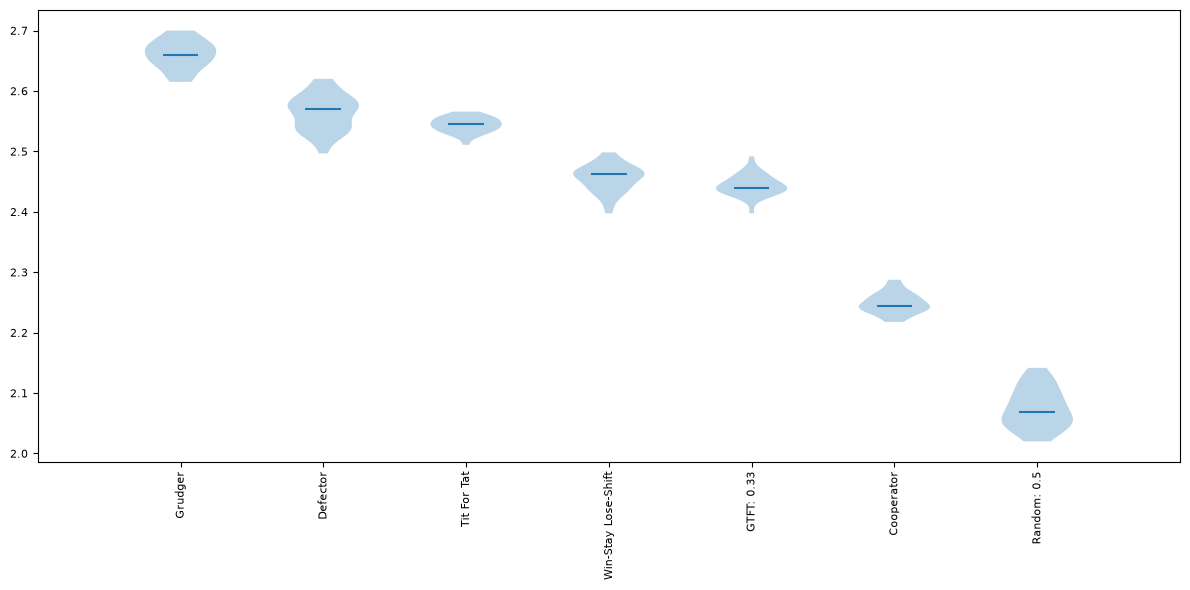

In [3]:
plot = axl.Plot(results)
figure = plot.boxplot()

figure.savefig(
    figure_directory / "baseline_scores.png",
    dpi=300,
    bbox_inches="tight",
)

figure.show()